In [150]:
import numpy as np
import matplotlib.pyplot as plt

Some parts of the codes could have been done only modifying the values referred to population A since we only use that, but I preferred to implement both for completeness.

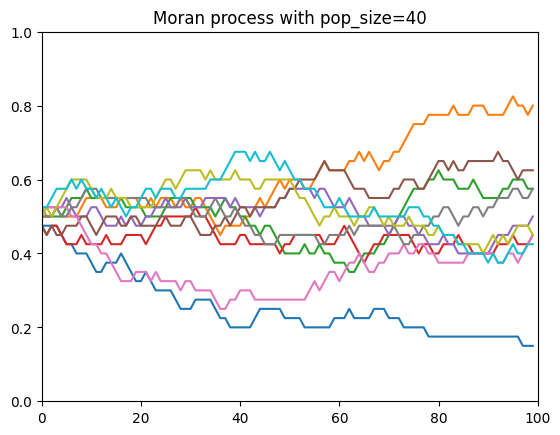

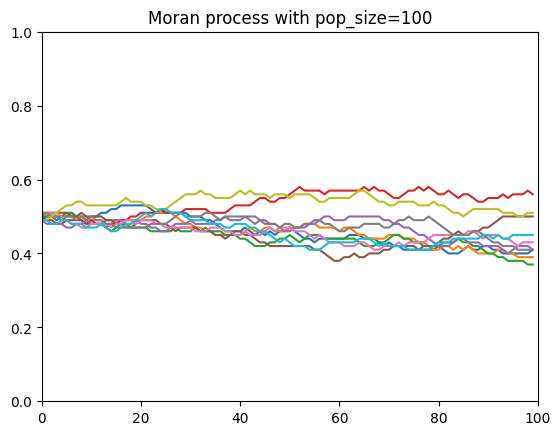

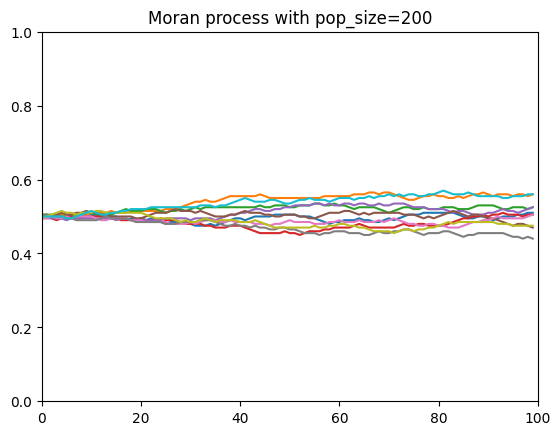

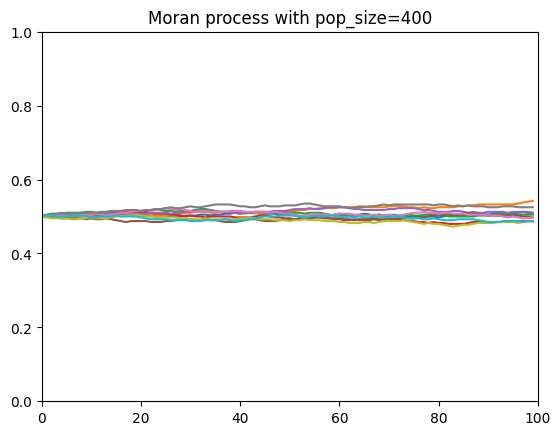

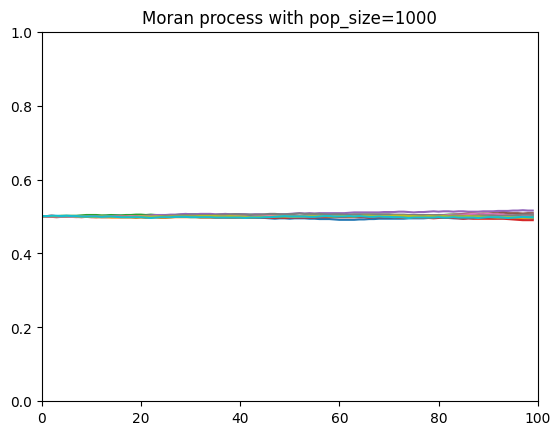

In [151]:
#np.random.seed(42)
t=np.arange(0,100) # just for this first part t is such "small"
n_sim=10

for pop_size in [40,100,200,400,1000]:
    a_size=int(pop_size/2)
    b_size=int(pop_size/2)

    for s in range(n_sim):
        
        a=np.zeros(a_size) #create population A
        b=np.ones(b_size) #create population B
        x=np.append(a,b)
        # print(a)
        # print(b)
        # print(x)
    
        prob_a=a_size/(a_size+b_size) #=a_size/len(x), ndr
        prob_b=b_size/(a_size+b_size)
        a_plot=np.zeros(np.size(t))
        # b_plot=np.zeros(np.size(t))
        for i in t:
            dead_idx=np.random.randint(0, pop_size)
            if x[dead_idx] == 0:
                prob_a=prob_a-1/((a_size+b_size))
            else:
                prob_b=prob_b-(1/(a_size+b_size))
            
            born_idx=np.random.randint(0, pop_size)
            if x[born_idx] == 0:
                prob_a=prob_a+1/((a_size+b_size))
            else:
                prob_b=prob_b+(1/(a_size+b_size))
            x[dead_idx]=x[born_idx]
            
            a_plot[i]=prob_a
            # b_plot[i]=prob_b
        plt.figure(pop_size)
        plt.axis([0,100,0,1]) # comment the line if generations are shown
        plt.title('Moran process with pop_size='+str(pop_size))
        plt.plot(t,a_plot) # or t/pop_size to see generations
        # plt.figure(2)
        # plt.plot(t,b_plot)
    plt.show()

As seen in the lecture, we can observe that with the smallest population size (40), the various simulations give very different results, while, as the population size grows, the spread between the simulations becomes smaller and stays longer in a neighbourhood of the starting value. This is due to the random sampling that in a small population leads to a higher stochasticity, since the choices fall in a smaller set of possible values.

Time has been taken small (t=100) just to have an initial idea of the trend of the model. Of course, for example for pop_size=1000, this choice of t is insufficient to give us meaningful information on the future, since it is just 1/10 of generation for this pop_size.
To convert between simulation steps and biological time, we just need to divide the number of timesteps by the population size: in this way we obtain the number of generations of the model, which is the biological time we usually look at. This makes even clearer that the number of steps has to be sufficiently large to observe biological effects of the process.